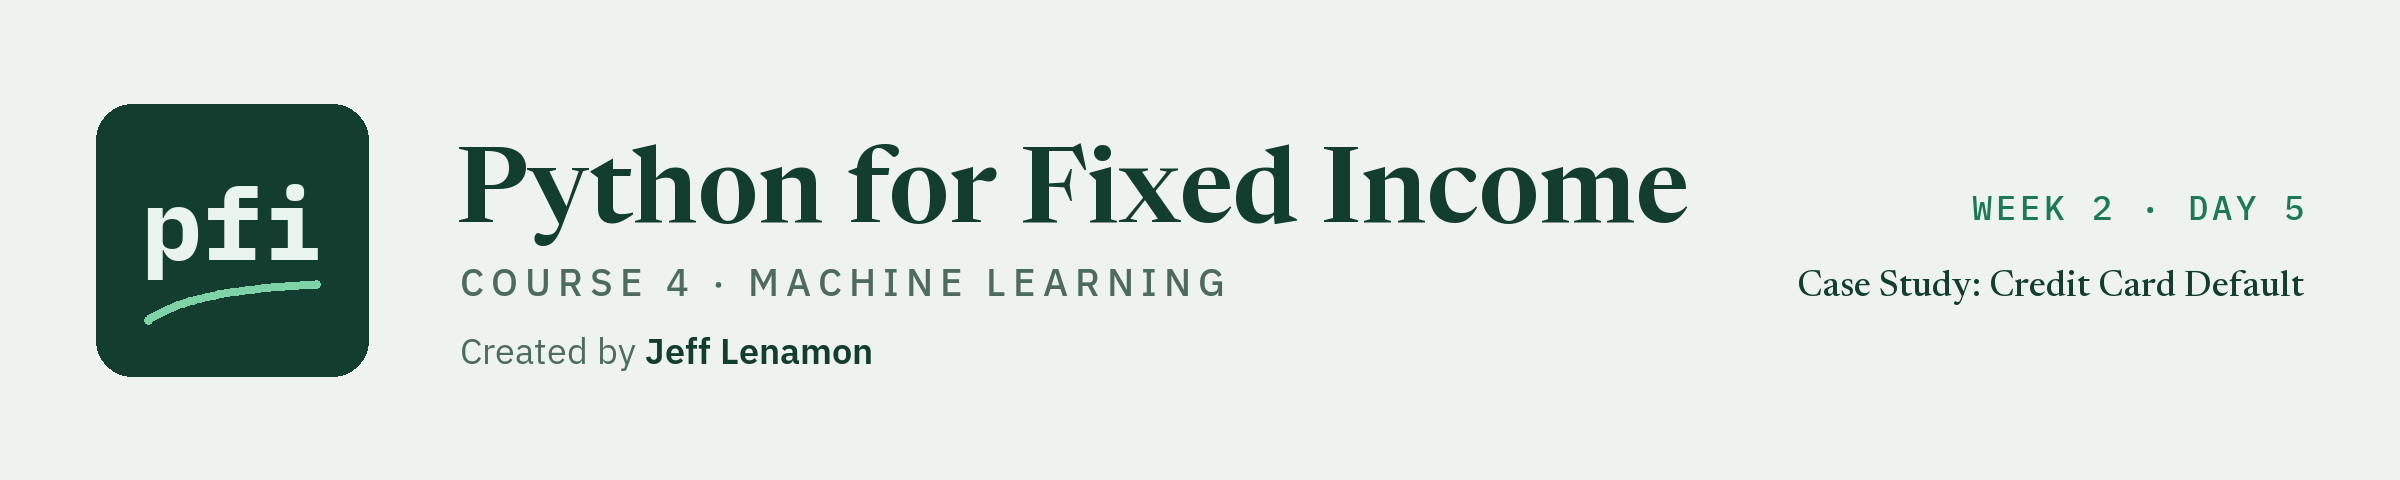

# Case Study: Credit Card Default

Week 2, Day 5. Week 2 ends with a case study: three models on the card file, each chosen on validation rows, then the test rows opened once, a results workbook, and a written description of what the model shows and where it fails.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week2/day5/10_case_study_credit_card_default.ipynb)

Days 6 to 9 built every piece: a logistic regression and its odds, the confusion matrix, a threshold chosen for recall on validation rows, and trees pruned by cross-validation. Every number so far came from the training or the validation rows. The test rows, 6,000 accounts, have been put away since day 6. **Today they are opened, once,** after every choice has been made.

The day has two halves.

**Hands-on, sections 10.1 to 10.3.**

1. Amounts with heavy tails, and `QuantileTransformer` inside the pipeline.
2. `compare_models`: one row of metrics per fitted model, on the rows you name. It fits nothing.
3. `assert_descriptive`: a check that a written description uses no forecast, advice, or lending word from its list.

**Case study, sections 10.4 to 10.12.** Three models compared on the card file: a logistic regression, the default tree with class weights, and a pruned tree. Each is fitted on training rows and chosen on validation rows; then the test rows report, once; then the people-attribute section, a two-sheet results workbook, and **What the Model Shows, and Where It Fails**.

**About the data.** The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender. The four columns that describe people, `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE`, are never model features in this course; section 10.10 says why and describes the chosen model's flags by the `SEX` label with counts. The split is week 2's: 60 percent training, 20 percent validation, 20 percent test, stratified, `random_state=SEED`.

A model's output on this file is called the **model probability of default in this file**, an account **flagged at threshold t**, or **the model's score**. It is never a credit decision, an approval, or a lending policy, and nothing in this notebook says what a lender should do.

Q. Set up today's work folder and copy today's four data files into it.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_10_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_10_zw14cpja, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name


from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


def pay0_flags(threshold: float = 0.5) -> tuple[pd.Series, np.ndarray]:
    """Actual defaults and flags of the logistic model on PAY_0, at Excel Solver's coefficients."""
    card = read_card()
    model = "d06_logit_default_on_pay0"
    z = excel(f"{model}:coef_const") + excel(f"{model}:coef_PAY_0") * card["PAY_0"]
    return card[CARD_TARGET], (mlkit.logistic_probability(z) >= threshold).astype(int)


def test_confusion_counts_hand():
    counts = mlkit.confusion_counts([0, 0, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0])
    assert counts == {"tn": 2, "fp": 1, "fn": 1, "tp": 2}


def test_confusion_counts_match_sklearn():
    y, flags = pay0_flags()
    counts = mlkit.confusion_counts(y, flags)
    tn, fp, fn, tp = confusion_matrix(y, flags).ravel()
    assert counts == {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    # Excel: =COUNTIFS(actual, 1, probability, ">=0.5") and the other three
    for name, value in counts.items():
        assert value == excel(f"d07_confusion_pay0_at_0.5:{name}")


def test_metrics_match_sklearn():
    y, flags = pay0_flags()
    metrics = mlkit.classification_metrics(y, flags)
    assert metrics["accuracy"] == pytest.approx(accuracy_score(y, flags), abs=1e-12)
    assert metrics["precision"] == pytest.approx(precision_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["recall"] == pytest.approx(recall_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["f1"] == pytest.approx(f1_score(y, flags, zero_division=0), abs=1e-12)
    for name in ("accuracy", "precision", "recall", "f1"):
        assert metrics[name] == pytest.approx(excel(f"d07_confusion_pay0_at_0.5:{name}"), abs=1e-12)


def test_metrics_zero_division():
    # a model that flags nothing: precision, recall, and F1 are 0 by convention, not an error
    metrics = mlkit.classification_metrics([0, 1, 1, 0], [0, 0, 0, 0])
    assert metrics == {"accuracy": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}


def test_rejects_labels_other_than_0_1():
    with pytest.raises(ValueError, match="other than 0 and 1"):
        mlkit.confusion_counts([0, 1, 2], [0, 1, 1])
    with pytest.raises(ValueError):
        mlkit.classification_metrics([0, 1], [True, 0.5])


from sklearn.metrics import roc_curve


def card_split() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """The card file's 60/20/20 split, stratified, seed 42: 18,000 training, 6,000 validation, 6,000 test rows.
    The four person columns (SEX, EDUCATION, MARRIAGE, AGE) and ID are never features."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
        [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X, y = card[features], card[CARD_TARGET]
    X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=SEED)
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def validation_proba() -> tuple[pd.Series, np.ndarray]:
    """Validation outcomes and probabilities of a scaled logistic regression fitted on the training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    return y_valid, model.predict_proba(X_valid)[:, 1]


def test_threshold_for_recall_hand():
    y = [1, 0, 1, 0, 1, 0]
    proba = [0.9, 0.8, 0.7, 0.4, 0.3, 0.1]
    # at 0.7 two of three defaults are caught (recall 2/3); at 0.3 all three
    assert mlkit.threshold_for_recall(y, proba, 0.6) == 0.7
    assert mlkit.threshold_for_recall(y, proba, 0.7) == 0.3
    assert mlkit.threshold_for_recall(y, proba, 1.0) == 0.3
    # tied probabilities are flagged together
    assert mlkit.threshold_for_recall([1, 1, 0, 1], [0.6, 0.5, 0.5, 0.2], 0.5) == 0.5


def test_threshold_meets_target():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    recall = mlkit.classification_metrics(y_valid, (proba >= threshold).astype(int))["recall"]
    assert recall >= 0.70
    # roc_curve flags rows with score >= threshold too: the true positive rate there is the same recall
    # (drop_intermediate=False keeps every distinct probability as a threshold)
    fpr, tpr, thresholds = roc_curve(y_valid, proba, drop_intermediate=False)
    assert tpr[thresholds == threshold][0] == pytest.approx(recall, abs=1e-12)


def test_threshold_is_highest():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    higher = np.unique(proba[proba > threshold])
    # the next distinct probability above the threshold misses the target
    next_up = higher.min()
    assert mlkit.classification_metrics(y_valid, (proba >= next_up).astype(int))["recall"] < 0.70


def test_threshold_rejects_bad_target():
    for target in (0.0, -0.1, 1.2):
        with pytest.raises(ValueError):
            mlkit.threshold_for_recall([0, 1], [0.2, 0.8], target)
    with pytest.raises(ValueError, match="no row of class 1"):
        mlkit.threshold_for_recall([0, 0], [0.2, 0.8], 0.5)


from sklearn.model_selection import KFold, StratifiedKFold


def test_cv_folds_classification_is_stratified():
    folds = mlkit.cv_folds()
    assert isinstance(folds, StratifiedKFold)
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)
    X_train, _, _, y_train, _, _ = card_split()
    overall = y_train.mean()
    for train_positions, test_positions in folds.split(X_train, y_train):
        mlkit.assert_disjoint(train_positions, test_positions)
        # each fold keeps the training rows' default rate to within one account
        assert abs(y_train.iloc[test_positions].mean() - overall) < 1 / len(test_positions) + 1e-12


def test_cv_folds_regression():
    folds = mlkit.cv_folds("regression")
    assert type(folds) is KFold
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)


def test_cv_folds_rejects_unknown():
    with pytest.raises(ValueError, match="time"):
        mlkit.cv_folds("time")

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability', 'confusion_counts', 'classification_metrics', 'threshold_for_recall', 'cv_folds']


* The two files exactly as day 9 left them: 13 functions and 38 passing tests. `_as_1d_array` and `_check_labels` start with an underscore: helpers, not counted. By the end of today there are 15 functions.

Today's Git step closes week 2 with a tag and compares it with week 1. This work folder is new, so it has no history; first we rebuild the one commit we need, as Course 3 did on its day 10. Week 1 ended just before `odds_ratios`, the first function of day 6, and just before the import block that opens day 6's tests. So the start of each file, up to that point, is exactly what week 1 left.

Q. Make the work folder a repository.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_10_zw14cpja and nowhere else


Q. Tell Git which files never to track: the bytecode cache, pytest's cache, and Excel workbooks.

In [7]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


Q. Cut both files back to the end of week 1.

In [8]:
# today's files, as the setup cell wrote them: keep them, to put them back after the week 1 commit
module_today = Path("mlkit.py").read_text(encoding="utf-8")
tests_today = Path("test_mlkit.py").read_text(encoding="utf-8")

# week 1 ended just before odds_ratios (day 6's first function) and day 6's first test import
module_week1 = module_today[:module_today.index("\n\n\ndef odds_ratios")] + "\n"
tests_week1 = tests_today[:tests_today.index("\n\n\nfrom sklearn.linear_model import LogisticRegression\n\nCARD_TARGET")] + "\n"
Path("mlkit.py").write_text(module_week1, encoding="utf-8")
Path("test_mlkit.py").write_text(tests_week1, encoding="utf-8")

# public functions start with "def " (helpers with "def _"), tests with "def test_"
week1_functions = sum(line.startswith("def ") and not line.startswith("def _") for line in module_week1.splitlines())
week1_tests = sum(line.startswith("def test_") for line in tests_week1.splitlines())
print(f"mlkit.py as week 1 left it: {week1_functions} functions; test_mlkit.py: {week1_tests} test functions")

mlkit.py as week 1 left it: 7 functions; test_mlkit.py: 20 test functions


* 7 functions and 20 test functions: week 1's regression module, from `assert_disjoint` to `named_coefficients`. `str.index` finds where a piece of text starts, and `[:position]` keeps everything before it. `module_today` and `tests_today` still hold today's full text.

Q. Commit the week 1 files, and name that commit `week1`.

In [9]:
# commit the week 1 files quietly, then put the name week1 on that commit
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Week 1 as it ended: mlkit.py and test_mlkit.py at the week1 tag"
!git -C "{work}" tag week1

Q. Put today's files back, and commit the start of day 10.

In [10]:
# put today's files back exactly as the setup cell wrote them
Path("mlkit.py").write_text(module_today, encoding="utf-8")
Path("test_mlkit.py").write_text(tests_today, encoding="utf-8")
print(f"mlkit.py: {sum(line.startswith('def ') and not line.startswith('def _') for line in module_today.splitlines())} functions again")

mlkit.py: 13 functions again


In [11]:
# commit the start-of-day files, then show the history with its names
!git -C "{work}" add mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Start of day 10: mlkit.py and test_mlkit.py as day 9 left them"
!git -C "{work}" log --oneline --decorate

20c52a5 (HEAD -> main) Start of day 10: mlkit.py and test_mlkit.py as day 9 left them
98b3a03 (tag: week1) Week 1 as it ended: mlkit.py and test_mlkit.py at the week1 tag


* Two commits. The older one carries `tag: week1`; the newer one, where `HEAD -> main` points, is the start of today. Hashes change on every run.

Q. Load the card file and make week 2's split: training, validation, and test rows.

In [12]:
# the 30,000 UCI card accounts (real data, Taiwan, 2005)
card = pd.read_csv("credit_card_default.csv")
TARGET = "default payment next month"

# the four columns that describe people are never features; ID only names the account
PERSON_COLUMNS = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
FEATURES = [column for column in card.columns if column not in ["ID", TARGET] + PERSON_COLUMNS]
X, y = card[FEATURES], card[TARGET]

from sklearn.model_selection import train_test_split

# 20 percent to the test rows first, then a quarter of the rest to validation: 60/20/20, stratified, one seed
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=SEED)

# no account in two parts
mlkit.assert_disjoint(X_train.index, X_valid.index)
mlkit.assert_disjoint(X_train.index, X_test.index)
mlkit.assert_disjoint(X_valid.index, X_test.index)
print(f"{len(FEATURES)} features; training {len(X_train):,}, validation {len(X_valid):,}, test {len(X_test):,} accounts")
print(f"default rate: training {y_train.mean():.2%}, validation {y_valid.mean():.2%}, test {y_test.mean():.2%}")

19 features; training 18,000, validation 6,000, test 6,000 accounts
default rate: training 22.12%, validation 22.12%, test 22.12%


* 18,000, 6,000, and 6,000 accounts, with the same default rate in each part (22.12, 22.12, and 22.12 percent): `stratify=y` keeps the share of defaults the same on every side. `assert_disjoint` passed three times in silence.
* `X_test` and `y_test` are now put away until section 10.9. Nothing in sections 10.1 to 10.8 reads them.

## 10.1 Heavy Tails, and `QuantileTransformer`

Bill and payment amounts on a card file are not spread evenly. Most accounts pay a few thousand NT dollars a month; a few pay hundreds of thousands. A logistic regression adds up its features times their coefficients, so one huge amount can push an account's log-odds a long way, and `StandardScaler` does not change that: it moves and stretches the numbers, and the gaps between them stay in proportion.

Q. How far do the largest amounts sit from the typical ones, on the training rows?

In [13]:
# three amount columns, in NT dollars: the median, the 99th percentile, the largest, and the skew
AMOUNTS = ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']
tails = X_train[AMOUNTS].describe(percentiles=[0.5, 0.99]).T[["50%", "99%", "max"]]
# skew is 0 for a symmetric spread; large and positive when a long tail runs to the right
tails["skew"] = X_train[AMOUNTS].skew()
tails.round({"50%": 0, "99%": 0, "max": 0, "skew": 2})

,50%,99%,max,skew
LIMIT_BAL,140000.0,500000.0,800000.0,1.00
BILL_AMT1,22339.0,342623.0,621749.0,2.59
PAY_AMT1,2100.0,69034.0,873552.0,16.39


* `PAY_AMT1`, the amount paid in September 2005: a median of 2,100 NT dollars and a largest payment of 873,552, about 416 times the median, with a skew of 16.39. `BILL_AMT1` has a skew of 2.59 and `LIMIT_BAL` 1.00.
* These are real amounts, not errors. They stay in the data; what changes is how the model reads them.

`QuantileTransformer(output_distribution="normal")` replaces each value by its **quantile** among the training rows (roughly, the share of rows at or below it), then maps that share to the matching point of a standard normal curve. The median goes to about 0 and the largest value to the top of the curve, however large it was. The order of the accounts is kept; the size of the gaps is not. It learns the quantiles from the rows it is fitted on, so it belongs inside the pipeline, fitted on training rows only. `random_state=SEED` is there because with more than 10,000 rows it learns the quantiles from a random sample of 10,000.

Q. What does the transform do to `PAY_AMT1`? Fit it on the training rows alone, once, to look.

PAY_AMT1 after the transform: from -5.20 to 5.20; accounts that paid 0 in September: 3,157


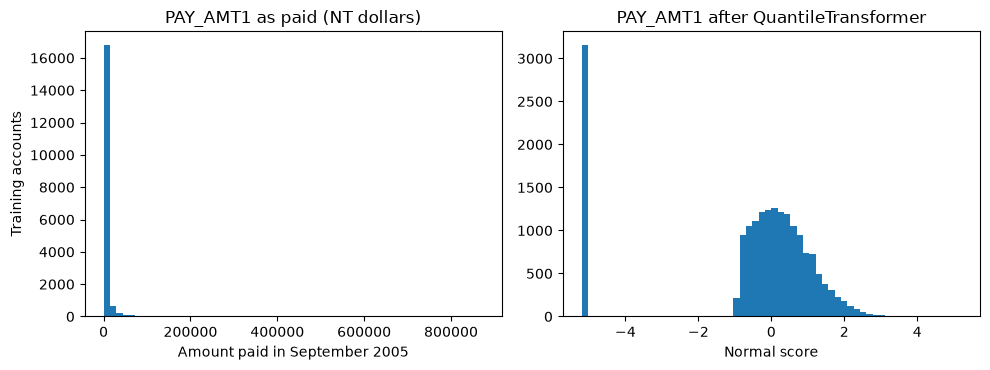

In [14]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer

# a demonstration, outside a pipeline, on the training rows only: to see what the transform does to one column
demo = QuantileTransformer(output_distribution="normal", random_state=SEED)
pay_normal = demo.fit_transform(X_train[["PAY_AMT1"]])
print(f"PAY_AMT1 after the transform: from {pay_normal.min():.2f} to {pay_normal.max():.2f}; "
      f"accounts that paid 0 in September: {(X_train['PAY_AMT1'] == 0).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].hist(X_train["PAY_AMT1"], bins=60)
axes[0].set_title("PAY_AMT1 as paid (NT dollars)")
axes[0].set_xlabel("Amount paid in September 2005")
axes[0].set_ylabel("Training accounts")
axes[1].hist(pay_normal[:, 0], bins=60)
axes[1].set_title("PAY_AMT1 after QuantileTransformer")
axes[1].set_xlabel("Normal score")
plt.tight_layout()
plt.show()

* On the left, almost every account sits in the first bar and the axis stretches to 873,552 for a handful. On the right, the same accounts spread from -5.20 to 5.20. The tall bar at the left is the 3,157 accounts that paid 0: tied values share one quantile, so they share one score.
* `QuantileTransformer` caps its normal scores near plus and minus 5.2 by design, so no single account can sit far beyond the rest.

Q. Does the transform change how well a logistic regression ranks the accounts? Compare it with `StandardScaler`, each inside a pipeline, by 5-fold cross-validation on the training rows and then on the validation rows.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# the same logistic regression behind two different first steps, each fitted inside its pipeline
pipelines = {
    "scaled": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
    "quantile": Pipeline([("quantile", QuantileTransformer(output_distribution="normal", random_state=SEED)),
                          ("model", LogisticRegression(max_iter=1000))]),
}
rows = {}
for name, pipeline in pipelines.items():
    # 5 folds of the training rows (mlkit.cv_folds): the transform is refitted inside each fold
    cv_auc = cross_val_score(pipeline, X_train, y_train, cv=mlkit.cv_folds(), scoring="roc_auc").mean()
    # then fitted once on all the training rows, and scored on the validation rows
    pipeline.fit(X_train, y_train)
    proba_valid = pipeline.predict_proba(X_valid)[:, 1]
    rows[name] = {"cv ROC AUC (training)": cv_auc,
                  "ROC AUC (validation)": roc_auc_score(y_valid, proba_valid),
                  "average precision (validation)": average_precision_score(y_valid, proba_valid)}
pd.DataFrame(rows).T.round(4)

,cv ROC AUC (training),ROC AUC (validation),average precision (validation)
scaled,0.7277,0.7190,0.4946
quantile,0.7366,0.7291,0.4594


* ROC AUC rises with the quantile transform, from 0.7277 to 0.7366 across the training folds and from 0.7190 to 0.7291 on the validation rows. The scores ranked behind these numbers are the **model probability of default in this file**.
* Average precision moves the other way on the validation rows: 0.4946 with `StandardScaler`, 0.4594 with the transform. ROC AUC weighs every pair of a default and a non-default equally; average precision weighs the top of the ranking, the accounts with the highest scores. Capping the largest amounts helps the ranking as a whole and costs something at the very top.
* The course compares models on the card file by ROC AUC on validation rows (week 2's convention), so the case study's logistic regression uses the quantile transform. The average precision column stays in every table below, because one number never tells the whole story.

## 10.2 `compare_models`: One Row per Model, Nothing Fitted

Each model so far gave its numbers in its own cell. A comparison needs them in one table, computed the same way for every model on the same rows: ROC AUC and average precision from the probabilities, then accuracy, precision, recall, and F1 at each model's own threshold.

Q. Add `compare_models` to `mlkit.py`. Read the docstring before you run the cell.

In [16]:
%%writefile -a mlkit.py


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")

Appending to mlkit.py


* It takes **fitted** models and calls only `predict_proba`. It never calls `fit`: the caller fits on training rows, and the rows given to `compare_models` only report. A model nobody fitted makes scikit-learn raise `NotFittedError`, rather than being fitted quietly on the rows it was meant to be judged on.
* Every model must have a threshold, chosen on rows other than the test rows; a missing one stops the function before anything is computed.
* Flags are `probability >= threshold`, the course's rule since day 8, and the four metrics come from `classification_metrics` (day 7).
* The word list at the top, `FORECAST_WORDS`, is not used by `compare_models`; it belongs to section 10.3's function.

Q. Add its two tests: the columns and values, and that nothing is refitted.

In [17]:
%%writefile -a test_mlkit.py


from sklearn.exceptions import NotFittedError
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier


def fitted_models() -> tuple[dict, pd.DataFrame, pd.Series]:
    """A scaled logistic regression and a depth-3 balanced tree fitted on the card training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    models = {
        "logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
        "tree": DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=SEED),
    }
    for model in models.values():
        model.fit(X_train, y_train)
    return models, X_valid, y_valid


def test_compare_models_columns():
    models, X_valid, y_valid = fitted_models()
    table = mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    assert list(table.index) == ["logistic", "tree"]
    assert list(table.columns) == ["roc_auc", "average_precision", "threshold", "accuracy", "precision", "recall",
                                   "f1"]
    proba = models["logistic"].predict_proba(X_valid)[:, 1]
    assert table.loc["logistic", "roc_auc"] == pytest.approx(roc_auc_score(y_valid, proba), abs=1e-12)
    assert table.loc["logistic", "average_precision"] == pytest.approx(average_precision_score(y_valid, proba),
                                                                         abs=1e-12)
    flags = (proba >= 0.2).astype(int)
    assert table.loc["logistic", "recall"] == pytest.approx(recall_score(y_valid, flags), abs=1e-12)
    with pytest.raises(ValueError, match="tree"):
        mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2})


def test_compare_models_does_not_refit():
    models, X_valid, y_valid = fitted_models()
    before = models["logistic"]["model"].coef_.copy()
    mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    # the coefficients learned on the training rows are untouched
    assert np.array_equal(models["logistic"]["model"].coef_, before)
    # and a model nobody fitted is refused, not fitted on the rows given
    with pytest.raises(NotFittedError):
        mlkit.compare_models({"new": LogisticRegression()}, X_valid, y_valid, {"new": 0.5})

Appending to test_mlkit.py


* `fitted_models` fits a scaled logistic regression and a depth-3 tree on the course split's training rows, so the tests check the function on the card file itself.
* `test_compare_models_does_not_refit` keeps a copy of the logistic coefficients, runs `compare_models`, and asserts they are unchanged; then it hands over a model nobody fitted and expects `NotFittedError`.

Q. Reload the module and run the tests.

In [18]:
# the file changed, so read it again
importlib.reload(mlkit)
print(f"compare_models in mlkit: {hasattr(mlkit, 'compare_models')}")

compare_models in mlkit: True


In [19]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........................................                                 [100%]
40 passed in 3.15s



* `40 passed`: the 38 from days 1 to 9 and two new ones.

Q. Compare the two pipelines of section 10.1 on the validation rows, each flagged at the threshold that catches at least 70 percent of the validation defaults.

In [20]:
# each model's threshold, chosen on the validation rows by the course's rule (day 8)
pipeline_thresholds = {name: mlkit.threshold_for_recall(y_valid, pipeline.predict_proba(X_valid)[:, 1], 0.70)
                       for name, pipeline in pipelines.items()}
mlkit.compare_models(pipelines, X_valid, y_valid, pipeline_thresholds).round(4)

,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
scaled,0.7190,0.4946,0.2025,0.6147,0.3268,0.7001,0.4456
quantile,0.7291,0.4594,0.2011,0.6708,0.3707,0.7001,0.4847


* One row per model, every column computed the same way. Flagged at threshold 0.2025, the scaled model catches 70.01 percent of the validation defaults with a precision of 32.68 percent; flagged at threshold 0.2011, the quantile model catches 70.01 percent with a precision of 37.07 percent.
* The thresholds differ because the two models' probabilities differ. Comparing them at one fixed threshold, say 0.5, would compare two different recalls. A threshold chosen for the same recall puts them on the same footing.

Q. What happens if a model has not been fitted?

In [21]:
# a new, unfitted model: compare_models must refuse it rather than fit it on the validation rows
try:
    mlkit.compare_models({"unfitted": LogisticRegression()}, X_valid, y_valid, {"unfitted": 0.5})
except Exception as error:
    print(f"{type(error).__name__}: the model was not fitted, so it was not scored")

NotFittedError: the model was not fitted, so it was not scored


* `NotFittedError`, from scikit-learn. A function that fitted a model on whatever rows it was handed would turn a report into a leak.

## 10.3 `assert_descriptive`: A Check on the Words

A case study ends in writing. On this course the writing describes: what the model separated, how well, on which rows it was wrong. It never says what a lender should do, never says what will happen, and never calls a result attractive. Those words slip in easily, so the module gets a check that stops on them.

Q. Add `assert_descriptive` to `mlkit.py`.

In [22]:
%%writefile -a mlkit.py


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")

Appending to mlkit.py


* It searches for each word of the list as a **whole word**, ignoring case: `\b` in the pattern marks a word boundary, so "willing" does not match "will".
* It raises `ValueError` naming every word it found, in the list's order.
* The docstring says it plainly: **the list is a reminder, not a proof.** A sentence can look ahead without any listed word, and a listed word can be harmless in context.

Q. Add the last two tests.

In [23]:
%%writefile -a test_mlkit.py


def test_assert_descriptive_passes_plain_text():
    mlkit.assert_descriptive("In this file the model ranked 72 percent of default and non-default pairs correctly. "
                             "A willing reader can check every number.")


def test_assert_descriptive_names_the_word():
    with pytest.raises(ValueError, match=r"\['will', 'cheap'\]"):
        mlkit.assert_descriptive("These bonds look Cheap and spreads WILL tighten.")

Appending to test_mlkit.py


In [24]:
# the file changed, so read it again
importlib.reload(mlkit)
print(f"mlkit functions: {[name for name, obj in vars(mlkit).items() if callable(obj) and getattr(obj, '__module__', '') == 'mlkit' and not name.startswith('_')]}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability', 'confusion_counts', 'classification_metrics', 'threshold_for_recall', 'cv_folds', 'compare_models', 'assert_descriptive']


In [25]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..........................................                               [100%]
42 passed in 3.14s



* `42 passed`. The module has 15 functions, and week 2 is complete.

Q. Which of these three sentences does the check stop?

In [26]:
sentences = [
    "In this file the pruned tree ranked default and non-default pairs better than the default tree.",
    "Accounts like these will default, so the desk should lend less to them.",
    "Defaults are going to rise next year.",
]
for sentence in sentences:
    try:
        mlkit.assert_descriptive(sentence)
        print(f"passes: {sentence}")
    except ValueError as error:
        print(f"stopped: {error}")

passes: In this file the pruned tree ranked default and non-default pairs better than the default tree.
stopped: the text uses forecast, advice, or lending words: ['will', 'should', 'lend']
passes: Defaults are going to rise next year.


* The first describes and passes. The second is stopped, and the message names all three words.
* The third passes, and it is not a description: it says what comes next. No list of words can catch every way of saying what comes next. The check makes the writer look again; the writer still has to read every sentence.

## Case Study: Credit Card Default

### Context

Course 1, notebook 16, described this file without a model: 30,000 credit card accounts, a 22.12 percent default rate, rates always with their counts. Week 2 has since built every tool a classification needs. A colleague asks the question this case study answers: **which of three standard models best separates the accounts that defaulted from those that did not, how well does it do on accounts it never saw, and where does it fail?**

The answer is a description of a historical dataset. It is not a lending rule, it ranks no person, and it says nothing about what anyone should do.

### Objective

1. Fit three models on the training rows: a logistic regression with the quantile transform, the default decision tree with class weights, and a tree pruned by cross-validation.
2. Choose each model's settings and threshold on training folds and validation rows only, at a recall of 0.70 on the validation rows.
3. Open the test rows once and report every model's numbers on them.
4. Describe the chosen model's flags by the `SEX` label, with counts, and say what that does and does not show.
5. Write a two-sheet results workbook and open it in Excel.
6. Write what the model shows, and where it fails.

### The data dictionary

Quoted from the "Additional Variable Information" section of the dataset page, as recorded in the course's `DATA.md`. Any statement about what a column means comes from this text.

> This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:
> X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
> X2: Gender (1 = male; 2 = female).
> X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
> X4: Marital status (1 = married; 2 = single; 3 = others).
> X5: Age (year).
> X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
> X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005.
> X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

The file names these columns `LIMIT_BAL` (X1), `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` (X2 to X5), `PAY_0` and `PAY_2` to `PAY_6` (X6 to X11; there is no `PAY_1`), `BILL_AMT1` to `BILL_AMT6`, `PAY_AMT1` to `PAY_AMT6`, then `default payment next month`. The models read the 19 columns that are not about people: `LIMIT_BAL`, the six repayment statuses, the six bill amounts, and the six payment amounts.

**What the documentation leaves open**, handled as notebook 16 handled it: the repayment status columns hold -2 and 0, which the documentation does not define. The models read `PAY_0` to `PAY_6` as numbers, codes included; treating the codes as an ordered number is a modelling choice, and the text says so wherever it matters. The page does not say how the accounts were chosen, does not name the lender, and gives the month of the outcome only through the column name.

**Place and period.** The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender.

## 10.4 Overview: the File, Described

Q. What is in the file as a whole? This is **description**, as in Course 1: no number from it is used to build a model.

In [27]:
# the whole file, described: accounts, defaults, the undefined September codes, and repeated rows
print(f"{len(card):,} accounts, {card[TARGET].sum():,} defaults: {card[TARGET].mean():.2%}")
print(f"PAY_0 code -2: {(card['PAY_0'] == -2).sum():,} accounts; code 0: {(card['PAY_0'] == 0).sum():,} (neither is defined)")
# rows that repeat another row once ID is set aside
print(f"rows that repeat an earlier row apart from ID: {card.drop(columns='ID').duplicated().sum()}")

30,000 accounts, 6,636 defaults: 22.12%
PAY_0 code -2: 2,759 accounts; code 0: 14,737 (neither is defined)
rows that repeat an earlier row apart from ID: 35


* The figures Course 1 found: 30,000 accounts, 6,636 defaults, 22.12 percent. Notebook 16 checked every column against the documentation and described the outcome against each one; that work is not repeated here.
* 17,496 accounts, more than half the file, carry an undefined September code: 2,759 with -2 and 14,737 with 0. Every model below reads them.
* 35 rows repeat another row in every column but `ID`. They are kept: different IDs mean different accounts that happen to share every number. (The capstone drops exact duplicates, which are copies of one record.)

## 10.5 Preparation: the Split, Checked by Account

The split was made at the start of the notebook, before any statistic was computed for a model. The row labels are positions in `card`, and `ID` is unique, so disjoint labels mean disjoint accounts. Today's AI check is about exactly that, so check it by `ID` too.

Q. Is any account ID in two parts of the split?

In [28]:
# the account IDs on each side
ids = {name: set(card.loc[part.index, "ID"]) for name, part in [("training", X_train), ("validation", X_valid), ("test", X_test)]}
for first, second in [("training", "validation"), ("training", "test"), ("validation", "test")]:
    print(f"IDs in both {first} and {second}: {len(ids[first] & ids[second])}")
print(f"all accounts used once: {sum(len(s) for s in ids.values()) == len(card)}")

IDs in both training and validation: 0
IDs in both training and test: 0
IDs in both validation and test: 0
all accounts used once: True


* No ID in two parts, and every account used exactly once. Preparation is otherwise inside the pipelines: the quantile transform is fitted on the training rows by `fit`, and refitted inside each cross-validation fold. Trees need no scaling (day 9).

## 10.6 Model Building: Logistic Regression and the Default Tree

Two models to start: the logistic regression of section 10.1 with the quantile transform, already fitted on the training rows, and the default tree with `class_weight="balanced"` (day 9), which gives the defaults as much total weight as the non-defaults.

Q. Fit the default tree on the training rows. How big is it, and how do its numbers on training rows compare with validation rows?

In [29]:
from sklearn.tree import DecisionTreeClassifier

# the logistic regression of section 10.1, fitted on the training rows
logistic = pipelines["quantile"]

# the default tree: no limit on depth or leaves, the defaults weighted up to balance the classes
tree_default = DecisionTreeClassifier(class_weight="balanced", random_state=SEED)
tree_default.fit(X_train, y_train)
proba_valid_default = tree_default.predict_proba(X_valid)[:, 1]

print(f"depth {tree_default.get_depth()}, {tree_default.get_n_leaves():,} leaves")
print(f"ROC AUC on training rows {roc_auc_score(y_train, tree_default.predict_proba(X_train)[:, 1]):.4f}, "
      f"on validation rows {roc_auc_score(y_valid, proba_valid_default):.4f}")
print(f"distinct probabilities on the validation rows: {np.unique(proba_valid_default).size}; "
      f"share of validation rows at exactly 0 or 1: {np.isin(proba_valid_default, [0.0, 1.0]).mean():.2%}")

depth 49, 3,233 leaves
ROC AUC on training rows 0.9997, on validation rows 0.6158
distinct probabilities on the validation rows: 28; share of validation rows at exactly 0 or 1: 97.62%


* Depth 49 and 3,233 leaves for 18,000 training accounts. Its ROC AUC is 0.9997 on the rows it grew on and 0.6158 on the validation rows: it has learned the training accounts one small leaf at a time.
* Most leaves hold accounts of one class only, so the tree's **model probability of default in this file** is 0 or 1 for 97.62 percent of validation accounts, with 28 distinct values in all. A probability that is nearly always 0 or 1 cannot rank accounts finely, which section 10.8 shows matters for the threshold.

## 10.7 Model Improvement: a Tree Pruned by Cross-Validation

Day 9's post-pruning: `ccp_alpha` charges each leaf a cost, so a larger alpha keeps fewer leaves. The alpha is chosen by `GridSearchCV` with `mlkit.cv_folds()` on the **training rows only**, by ROC AUC across the five folds. The grid is 0.0002, 0.0005, 0.001, 0.002, 0.005.

Q. Which alpha gives the best cross-validated ROC AUC, and how big is the tree it keeps?

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import export_text

# five folds of the training rows choose ccp_alpha; the validation and test rows take no part
search = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
                      {"ccp_alpha": [0.0002, 0.0005, 0.001, 0.002, 0.005]}, cv=mlkit.cv_folds(), scoring="roc_auc")
search.fit(X_train, y_train)

# the mean ROC AUC across the five folds for each alpha
print(pd.Series(search.cv_results_["mean_test_score"], index=search.cv_results_["param_ccp_alpha"].astype(float),
                name="cv ROC AUC").round(4).to_string())
# refit=True (the default) refits the best alpha on all the training rows
tree_pruned = search.best_estimator_
print(f"best ccp_alpha {search.best_params_['ccp_alpha']}: depth {tree_pruned.get_depth()}, {tree_pruned.get_n_leaves()} leaves")

0.0002    0.6838
0.0005    0.7589
0.0010    0.7598
0.0020    0.7496
0.0050    0.7369
best ccp_alpha 0.001: depth 6, 12 leaves


* Cross-validated ROC AUC rises from 0.6838 at the smallest alpha to 0.7598 at 0.001 and falls to 0.7369 at the largest: too little pruning keeps noise, too much cuts real structure. The chosen alpha sits inside the grid, not at an edge, so the grid was wide enough.
* The pruned tree has depth 6 and 12 leaves, against 3,233. Small enough to read.

Q. Read the pruned tree as rules.

In [31]:
# each line is a question; "class" is the leaf's majority after the class weights
print(export_text(tree_pruned, feature_names=FEATURES))

|--- PAY_0 <= 0.50
|   |--- PAY_AMT2 <= 1605.50
|   |   |--- PAY_3 <= 1.00
|   |   |   |--- PAY_AMT1 <= 1372.50
|   |   |   |   |--- class: 0
|   |   |   |--- PAY_AMT1 >  1372.50
|   |   |   |   |--- class: 0
|   |   |--- PAY_3 >  1.00
|   |   |   |--- class: 1
|   |--- PAY_AMT2 >  1605.50
|   |   |--- PAY_4 <= 1.00
|   |   |   |--- LIMIT_BAL <= 75000.00
|   |   |   |   |--- class: 0
|   |   |   |--- LIMIT_BAL >  75000.00
|   |   |   |   |--- BILL_AMT2 <= 3631.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- BILL_AMT2 >  3631.50
|   |   |   |   |   |--- BILL_AMT1 <= 70362.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- BILL_AMT1 >  70362.50
|   |   |   |   |   |   |--- class: 0
|   |   |--- PAY_4 >  1.00
|   |   |   |--- class: 1
|--- PAY_0 >  0.50
|   |--- PAY_0 <= 1.50
|   |   |--- PAY_2 <= 1.50
|   |   |   |--- PAY_AMT3 <= 1.00
|   |   |   |   |--- class: 1
|   |   |   |--- PAY_AMT3 >  1.00
|   |   |   |   |--- class: 0
|   |   |--- PAY_2 >  1.50
|   |   |

* The first question is `PAY_0 <= 0.50`: whether the September status is 0 or below (paid duly, or one of the two undefined codes) or a delay of one month or more. The tree uses 10 of the 19 columns: `BILL_AMT1`, `BILL_AMT2`, `LIMIT_BAL`, `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_AMT1`, `PAY_AMT2`, `PAY_AMT3`.
* `PAY_0 <= 0.50` splits the codes as numbers: -2, -1, and 0 on one side. That is the modelling choice of treating the codes as ordered, made visible.
* A leaf's class is shown after the class weights, so "class: 1" means the weighted defaults outnumber the weighted non-defaults in that leaf, not that most of its accounts defaulted.

## 10.8 Comparison on Validation Rows, and the Threshold

Three models, each fitted on the training rows. Now the validation rows choose: a threshold for each model by `threshold_for_recall` at 0.70, an illustration of a desk that asks to catch 70 percent of defaults, and then the model with the highest validation ROC AUC.

Q. Choose each model's threshold on the validation rows, and compare the three models there.

In [32]:
models = {"logistic": logistic, "tree_default": tree_default, "tree_pruned": tree_pruned}

# the course's threshold rule, on validation rows only: the highest threshold with recall at least 0.70
thresholds = {name: mlkit.threshold_for_recall(y_valid, model.predict_proba(X_valid)[:, 1], 0.70)
              for name, model in models.items()}
valid_table = mlkit.compare_models(models, X_valid, y_valid, thresholds)

# the model with the highest ROC AUC on the validation rows is the one carried to the people section
chosen = valid_table["roc_auc"].idxmax()
print(f"chosen on validation ROC AUC: {chosen}")
valid_table.round(4)

chosen on validation ROC AUC: tree_pruned


,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic,0.7291,0.4594,0.2011,0.6708,0.3707,0.7001,0.4847
tree_default,0.6158,0.2926,0.0000,0.2212,0.2212,1.0000,0.3622
tree_pruned,0.7627,0.4954,0.4608,0.6945,0.3938,0.7069,0.5058


* The pruned tree has the highest validation ROC AUC, 0.7627, then the logistic regression at 0.7291 and the default tree at 0.6158. The pruned tree also has the highest average precision, 0.4954.
* **The default tree's threshold is 0.** Its probabilities are almost all 0 or 1, and the accounts it scores 1 hold fewer than 70 percent of the validation defaults, so the only threshold that reaches the target flags every account: recall 1.0000, precision 0.2212 (the default rate itself), accuracy 0.2212. The rule did what it was asked; the model gave it nothing in between.
* Flagged at threshold 0.4608, the pruned tree catches 70.69 percent of validation defaults with precision 39.38 percent. With 12 leaves it has at most 12 distinct probabilities, so its recall moves in steps and lands above 0.70 rather than on it. The logistic regression, flagged at 0.2011, reaches 70.01 percent with precision 37.07 percent.
* Every number here is the model's output on validation rows, which chose the thresholds; they are one step optimistic. Section 10.9 reports on rows that chose nothing.

Q. Draw the three ROC curves on the validation rows.

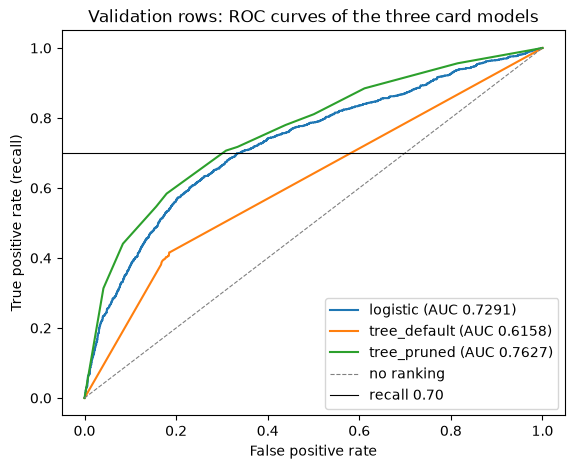

In [33]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6.5, 5))
for name, model in models.items():
    # every threshold at once: false positive rate against true positive rate (recall)
    fpr, tpr, _ = roc_curve(y_valid, model.predict_proba(X_valid)[:, 1])
    ax.plot(fpr, tpr, label=f"{name} (AUC {valid_table.loc[name, 'roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linewidth=0.8, linestyle="--", label="no ranking")
ax.axhline(0.70, color="black", linewidth=0.8, label="recall 0.70")
ax.set_title("Validation rows: ROC curves of the three card models")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (recall)")
ax.legend(loc="lower right")
plt.show()

* The pruned tree's curve is a few straight segments, one per leaf; the logistic curve is smooth, because every account gets its own probability. The default tree's curve is nearly a single corner, then a straight line to (1, 1): it ranks almost nothing between its two values.
* Where each curve crosses the recall line is its threshold's operating point. At recall 0.70 the pruned tree flags fewer non-defaults than the logistic regression, which is the precision difference in the table.

## 10.9 The Test Rows, Opened Once

Every choice is made: the features, the transform, the alpha, the three thresholds, and the model carried forward. Nothing below changes any of them. The test rows, put away since day 6, now report.

Q. Score the three models on the 6,000 test rows, at the thresholds chosen on validation rows.

In [34]:
# the one look: compare_models fits nothing; the thresholds come from the validation rows
test_table = mlkit.compare_models(models, X_test, y_test, thresholds)
# each model's probabilities and flags on the test rows, kept for the sections that report on them
proba_test = {name: model.predict_proba(X_test)[:, 1] for name, model in models.items()}
flags_test = {name: (proba_test[name] >= thresholds[name]).astype(int) for name in models}

print(f"all-zero baseline accuracy on the test rows: {1 - y_test.mean():.4f}")
test_table.round(4)

all-zero baseline accuracy on the test rows: 0.7788


,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic,0.7214,0.4584,0.2011,0.6575,0.3571,0.6858,0.4697
tree_default,0.6128,0.2887,0.0000,0.2212,0.2212,1.0000,0.3622
tree_pruned,0.7544,0.4903,0.4608,0.6810,0.3799,0.6993,0.4923


* On rows that chose nothing, the order holds: pruned tree 0.7544, logistic regression 0.7214, default tree 0.6128.
* The pruned tree's numbers are a little lower than on validation: ROC AUC 0.7627 to 0.7544, recall 0.7069 to 0.6993, precision 0.3938 to 0.3799. That is the expected direction: the validation rows chose its threshold, so its validation recall was the best of the steps available there. The recall target of 0.70 is not met on the test rows, and the text says so instead of moving the threshold. Moving it now would be tuning on the test set.
* Accuracy sits beside the all-zero baseline of 0.7788, which flags no account at all. The pruned tree's accuracy, 0.6810, is below it: at recall 0.70 it flags many non-defaults. Accuracy was never the measure chosen on: on this file it favours the all-zero baseline, which catches no default.

Q. The four counts behind each model's test row.

In [35]:
# true negatives, false positives, false negatives, true positives on the test rows, class 1 = default
counts = pd.DataFrame({name: mlkit.confusion_counts(y_test, flags_test[name]) for name in models}).T
counts["flagged"] = counts["fp"] + counts["tp"]
counts

,tn,fp,fn,tp,flagged
logistic,3035,1638,417,910,2548
tree_default,0,4673,0,1327,6000
tree_pruned,3158,1515,399,928,2443


* Flagged at threshold 0.4608, the pruned tree flags 2,443 of 6,000 test accounts. 928 of them defaulted and 1,515 did not; 399 of the 1,327 test defaults were not flagged.
* The default tree flags all 6,000: 0 true negatives, as its threshold of 0 implies.

## 10.10 People Attributes

The file has four columns that describe people: `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE`. **They are never model features in this course.** The reasons, in plain words: the course describes a file and builds no lending rule; a model that used these columns would sort people by them; and leaving them out does not make a model neutral, because the other columns can carry the same information.

Q. How much do the four columns change a model's ranking on this file? Cross-validate the logistic regression on the training rows with and without them, once, as a fact about this file.

In [36]:
# the same pipeline, the same folds, the same training rows: 19 columns, then the 19 plus the four person columns
X_train_people = card.loc[X_train.index, FEATURES + PERSON_COLUMNS]
without = cross_val_score(logistic, X_train_people[FEATURES], y_train, cv=mlkit.cv_folds(), scoring="roc_auc").mean()
with_people = cross_val_score(logistic, X_train_people, y_train, cv=mlkit.cv_folds(), scoring="roc_auc").mean()
print(f"cv ROC AUC on training rows: without the four columns {without:.4f}, with them {with_people:.4f}")

cv ROC AUC on training rows: without the four columns 0.7366, with them 0.7368


* 0.7366 without and 0.7368 with: the four columns change the cross-validated ROC AUC by less than 0.001. Leaving them out costs almost nothing in ranking here. That is a fact about this file and this model; it is not why they are left out, and it would not make them acceptable if it were larger.
* Apart from exercise 2, which reports one more fact of this kind, this is the only model in the course fitted with them, and it is used for nothing but this comparison.

Q. Describe the chosen model's flags on the test rows by the `SEX` label: accounts, the flag rate, and the recall, each with its count and Course 1's rough margin.

In [37]:
# the documented labels of SEX, from the dataset page
sex = card.loc[X_test.index, "SEX"].map({1: "male", 2: "female"})
groups = pd.DataFrame({"sex": sex, "default": y_test, "flag": flags_test[chosen]})

by_sex = groups.groupby("sex").agg(accounts=("flag", "size"), flagged=("flag", "sum"), defaults=("default", "sum"))
by_sex["defaults_flagged"] = groups[groups["default"] == 1].groupby("sex")["flag"].sum()
# rates as fractions first; Course 1's rough margin, 1.96 x sqrt(p x (1 - p) / n), in percentage points
p_flag = by_sex["flagged"] / by_sex["accounts"]
p_recall = by_sex["defaults_flagged"] / by_sex["defaults"]
by_sex["flag_rate_pct"] = (p_flag * 100).round(2)
by_sex["flag_margin_pts"] = (1.96 * np.sqrt(p_flag * (1 - p_flag) / by_sex["accounts"]) * 100).round(2)
by_sex["recall_pct"] = (p_recall * 100).round(2)
by_sex["recall_margin_pts"] = (1.96 * np.sqrt(p_recall * (1 - p_recall) / by_sex["defaults"]) * 100).round(2)
by_sex

,accounts,flagged,defaults,defaults_flagged,flag_rate_pct,flag_margin_pts,recall_pct,recall_margin_pts
sex,,,,,,,,
female,3598,1467,766,539,40.77,1.61,70.37,3.23
male,2402,976,561,389,40.63,1.96,69.34,3.82


* Flagged at threshold 0.4608: 40.77 percent of the 3,598 test accounts labelled `female` (give or take about 1.61 points) and 40.63 percent of the 2,402 labelled `male` (about 1.96 points).
* Recall: 539 of 766 defaults flagged for `female`, 70.37 percent (about 3.23 points), and 389 of 561 for `male`, 69.34 percent (about 3.82 points). Each gap is smaller than the rough margins on either side.
* Differences between groups in this file do not explain themselves, and they are not a basis for treating people differently. (Course 1, notebook 16, word for word.)

**What this does and does not show.** It shows how often the chosen model flagged test accounts with each label, and what share of each label's defaults it flagged, with the counts behind each rate. It does not show that the model is fair, or unfair. Published fairness measures exist, among them equal flag rates across groups, equal recall, and equal precision, and they can disagree with each other: when two groups have different default rates, a model generally cannot make all of them equal at once. This course does not certify any model as fair. The margin is the rough guide of Course 1: it treats the accounts as a random draw, and the page does not say how they were chosen.

## 10.11 The Results Workbook

A comparison often leaves the notebook as a workbook. Two sheets: `comparison`, one row per model and set of rows (validation first, then test), and `confusion`, the four counts behind each test row.

Q. Write `card_default_results.xlsx` with `pd.ExcelWriter`, then read it back and check that nothing changed on the way.

In [38]:
# one table per sheet: the comparison on validation rows, then on test rows, and the test counts
comparison = pd.concat([valid_table.assign(rows="validation"), test_table.assign(rows="test")]).rename_axis("model").reset_index()
comparison = comparison[["model", "rows", "roc_auc", "average_precision", "threshold", "accuracy", "precision", "recall", "f1"]]
confusion = counts.rename_axis("model").reset_index().assign(threshold=lambda t: t["model"].map(thresholds))
confusion = confusion[["model", "threshold", "tn", "fp", "fn", "tp"]]

# ExcelWriter with openpyxl, one sheet per table; the workbook goes in the work folder, never in the course folder
with pd.ExcelWriter("card_default_results.xlsx", engine="openpyxl") as writer:
    comparison.to_excel(writer, sheet_name="comparison", index=False)
    confusion.to_excel(writer, sheet_name="confusion", index=False)

# sheet_name=None reads every sheet, in the workbook's order
back = pd.read_excel("card_default_results.xlsx", sheet_name=None)
print(f"sheets: {list(back)}; comparison {back['comparison'].shape}, confusion {back['confusion'].shape}")
pd.testing.assert_frame_equal(back["comparison"], comparison, check_exact=False, rtol=1e-12)
pd.testing.assert_frame_equal(back["confusion"], confusion, check_dtype=False)
print("both sheets equal after the round trip")

sheets: ['comparison', 'confusion']; comparison (6, 9), confusion (3, 6)
both sheets equal after the round trip


* Two sheets, in the order written, and every number back. The counts come back as whole numbers; `check_dtype=False` lets the integer type differ, not the values.

**What Excel shows.** Tested in Excel: the workbook this notebook writes was opened in desktop Excel with `Workbooks.Open` (Excel 16.0 build 20430, 2026-10-04). It has two sheets, `comparison` and `confusion`, in that order. Row 1 holds the column names and column A the model's name; there is no index column, because the tables were written with `index=False`. No number format was set, so each number shows in Excel's General format, as many digits as fit a column of the standard width (8.09 characters): the pruned tree's test row shows `tree_pruned | test | 0.754371 | 0.490291 | 0.460839 | 0.681 | 0.379861 | 0.699322 | 0.492308`. A cell holds every digit even where it shows fewer: its ROC AUC cell holds 0.754370575663462, which the formula bar shows when you click it. No cell showed `####`. Section Excel Side by Side reads the sheets with formulas.

## 10.12 What the Model Shows, and Where It Fails

Q. On which test accounts is the chosen model wrong? Split its misses and its false flags by the September status.

In [39]:
pay_0 = card.loc[X_test.index, "PAY_0"]
flags = flags_test[chosen]
missed = (y_test == 1) & (flags == 0)
false_flags = (y_test == 0) & (flags == 1)
print(f"defaults not flagged: {missed.sum():,}; of them with a September status of 0 or below: {(missed & (pay_0 <= 0)).sum():,}")
print(f"test defaults with a September status of 0 or below: {((y_test == 1) & (pay_0 <= 0)).sum():,}")
print(f"non-defaults flagged: {false_flags.sum():,}; of them with a September delay of 1 month or more: {(false_flags & (pay_0 >= 1)).sum():,}")

defaults not flagged: 399; of them with a September status of 0 or below: 379
test defaults with a September status of 0 or below: 667
non-defaults flagged: 1,515; of them with a September delay of 1 month or more: 561


* 379 of the 399 defaults the tree did not flag had a September status of 0 or below. Of the 667 test defaults with such a status, it flagged 288. The tree finds defaults mostly through a recent delay; an account that defaulted after a September with no recorded delay mostly goes unflagged.
* 561 of its 1,515 false flags had a September delay of a month or more: accounts that were late and did not default the next month.

Q. Write the description, and check its words.

In [40]:
row = test_table.loc[chosen]
# plain names for the three models, for the sentence
plain = {"logistic": "logistic regression", "tree_default": "default tree", "tree_pruned": "pruned tree"}
counts_chosen = mlkit.confusion_counts(y_test, flags_test[chosen])
description = (
    f"On the {len(X_test):,} test rows of the UCI card file (accounts in Taiwan in 2005), the {plain[chosen]} had a "
    f"ROC AUC of {row['roc_auc']:.4f}, against {test_table.loc['logistic', 'roc_auc']:.4f} for the logistic regression "
    f"and {test_table.loc['tree_default', 'roc_auc']:.4f} for the default tree. Flagged at threshold {row['threshold']:.4f}, "
    f"chosen on validation rows for a recall of 0.70, it flagged {counts_chosen['tp'] + counts_chosen['fp']:,} accounts "
    f"and {counts_chosen['tp']:,} of the {counts_chosen['tp'] + counts_chosen['fn']:,} defaults (recall {row['recall']:.4f}, "
    f"below the 0.70 it reached on validation rows); {row['precision']:.2%} of the flagged accounts defaulted. "
    f"It separates accounts mainly by the September repayment status: {(missed & (pay_0 <= 0)).sum():,} of the "
    f"{missed.sum():,} defaults it missed had a September status of 0 or below. The default tree fitted its training "
    f"rows almost exactly and reached the recall target on validation rows only by flagging every account. "
    f"The file covers one place and one period, the documentation does not say how the accounts were chosen, and two "
    f"of the repayment codes the model reads are not defined there."
)
# stops on a forecast, advice, or lending word; a reminder, not a proof
mlkit.assert_descriptive(description)
print(description)

On the 6,000 test rows of the UCI card file (accounts in Taiwan in 2005), the pruned tree had a ROC AUC of 0.7544, against 0.7214 for the logistic regression and 0.6128 for the default tree. Flagged at threshold 0.4608, chosen on validation rows for a recall of 0.70, it flagged 2,443 accounts and 928 of the 1,327 defaults (recall 0.6993, below the 0.70 it reached on validation rows); 37.99% of the flagged accounts defaulted. It separates accounts mainly by the September repayment status: 379 of the 399 defaults it missed had a September status of 0 or below. The default tree fitted its training rows almost exactly and reached the recall target on validation rows only by flagging every account. The file covers one place and one period, the documentation does not say how the accounts were chosen, and two of the repayment codes the model reads are not defined there.


The description passes the check, and it was read sentence by sentence as well, because the check is a reminder, not a proof. Every number in it is the model's output on rows that chose nothing.

**What the model shows.** On this file, a tree with 12 leaves separates defaults from non-defaults better than the logistic regression and far better than the unpruned tree, by ROC AUC on validation and on test rows. It does so mostly through the repayment statuses, `PAY_0` first.

**Where it fails.**

* **On rows.** Defaults with no recorded September delay are mostly missed, and late accounts that did not default are often flagged. At recall 0.70, 62.01 percent of flagged test accounts did not default.
* **On the target.** Recall on the test rows, 0.6993, fell short of the 0.70 chosen on validation rows: a threshold set on one set of rows is not a guarantee on another.
* **On the codes.** The tree's first split reads the undefined codes -2 and 0 as numbers below 1. If the codes mean something the order does not capture, the split's reading changes; the documentation cannot settle it.

**What the data cannot support.** The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender. The page does not say how the accounts were chosen, or exactly when the outcome was measured. The model's probabilities describe this file; they are not a risk measure for any person, and no threshold here is a lending rule.

**What was not tested.** Other seeds and other splits; other model families (Course 5); calibration of the tree's probabilities (day 8 showed one chart for the logistic model, none here); whether the relationships hold in a later period, since the file has no later accounts; and any cost attached to a missed default or a false flag, which this course does not assign.

## Excel Side by Side

Excel has no logistic fit as a worksheet function (Solver fits one, day 6) and no decision tree (day 9 wrote a depth-2 tree as nested `IF`), so the models stay in Python. What Excel does well is read a results workbook and check it. Every formula below was typed into Excel by script on the workbook this notebook writes, and on the CSV file the next cell writes (Excel 16.0 build 20430, 2026-10-04).

**1. The test row metrics, from the four counts.** On the `confusion` sheet, columns C to F hold `tn`, `fp`, `fn`, `tp`. In H2, `=F2/(F2+D2)` is precision; in I2, `=F2/(F2+E2)` is recall; in J2, `=(C2+F2)/SUM(C2:F2)` is accuracy; in K2, `=(D2+F2)/SUM(C2:F2)` is the share of accounts flagged. Filled down rows 2 to 4, they return the `comparison` sheet's test values for every model, within 1e-12:

| Model | precision | recall | accuracy |
| --- | --- | --- | --- |
| `logistic` | 0.3571 | 0.6858 | 0.6575 |
| `tree_default` | 0.2212 | 1.0000 | 0.2212 |
| `tree_pruned` | 0.3799 | 0.6993 | 0.6810 |

**2. Which model has the highest validation ROC AUC.** On the `comparison` sheet, rows 2 to 4 hold the validation rows and column C the ROC AUC: `=INDEX(A2:A4,MATCH(MAX(C2:C4),C2:C4,0))` returned `tree_pruned`, the model section 10.8 chose. `MAX` finds the largest value, `MATCH(..., 0)` finds its position by exact match, and `INDEX` returns the model name in that position.

**3. Flag rate and recall by the `SEX` code.** Open `test_flags.csv` (written below) in Excel: A `ID`, B `SEX`, C `default`, D `flag`, 6,000 rows. The flag rate for code 1 is `=COUNTIFS(B2:B6001,1,D2:D6001,1)/COUNTIF(B2:B6001,1)`; the recall is `=COUNTIFS(B2:B6001,1,C2:C6001,1,D2:D6001,1)/COUNTIFS(B2:B6001,1,C2:C6001,1)`, the defaults flagged over all defaults; `=COUNTIF(B2:B6001,1)` counts the accounts. For code 2, change the 1 after each `B2:B6001` to 2; the 1s after `C2:C6001` and `D2:D6001` stay, because they pick defaults and flags. Excel returned the counts and rates of section 10.10.

Q. Write each test account's `SEX` code, outcome, and the chosen model's flag to `test_flags.csv`, for the `COUNTIFS` above.

In [41]:
# one row per test account: no probability, only what the counts need
flag_file = pd.DataFrame({"ID": card.loc[X_test.index, "ID"], "SEX": card.loc[X_test.index, "SEX"],
                          "default": y_test, "flag": flags_test[chosen]})
flag_file.to_csv("test_flags.csv", index=False)
print(f"test_flags.csv: {len(flag_file):,} rows, columns {list(flag_file.columns)}")

test_flags.csv: 6,000 rows, columns ['ID', 'SEX', 'default', 'flag']


In [42]:
# what Excel returned (from the day's Excel check), beside the same numbers from Python
excel_by_code = {1: {'accounts': 2402.0, 'flag_rate': 0.4063280599500416, 'recall': 0.6934046345811051}, 2: {'accounts': 3598.0, 'flag_rate': 0.4077265147304058, 'recall': 0.7036553524804178}}
for code, label in [(1, "male"), (2, "female")]:
    python_values = {"accounts": int(by_sex.loc[label, "accounts"]),
                     "flag_rate": by_sex.loc[label, "flagged"] / by_sex.loc[label, "accounts"],
                     "recall": by_sex.loc[label, "defaults_flagged"] / by_sex.loc[label, "defaults"]}
    same = all(abs(excel_by_code[code][key] - python_values[key]) < 1e-12 for key in python_values)
    print(f"SEX code {code} ({label}): {python_values['accounts']:,} accounts, flag rate {python_values['flag_rate']:.4f}, "
          f"recall {python_values['recall']:.4f}; Excel within 1e-12: {same}")

SEX code 1 (male): 2,402 accounts, flag rate 0.4063, recall 0.6934; Excel within 1e-12: True
SEX code 2 (female): 3,598 accounts, flag rate 0.4077, recall 0.7037; Excel within 1e-12: True


* Excel's `COUNTIFS` and pandas' `groupby` give the same counts, so the same rates. In Excel the counts sit in plain sight beside each rate, which is where they belong.

## Save the Day with Git

Commit today's code, then the experiment log in two steps: the comparison on validation rows, which chose everything, and then the test rows, opened once. Then close week 2 with a tag and compare it with week 1.

Q. What changed since the start-of-day commit?

In [43]:
# untracked files are marked ??; the data copies and test_flags.csv stay untracked, the workbook is ignored
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M mlkit.py
 M test_mlkit.py
?? benchmark.csv
?? course4_excel_reference.csv
?? credit_card_default.csv
?? ratings.csv
?? test_flags.csv


 mlkit.py      | 53 +++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_mlkit.py | 54 ++++++++++++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 107 insertions(+)


Q. Commit the module and its tests.

In [44]:
!git -C "{work}" add mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Add compare_models and assert_descriptive, with four tests"
!git -C "{work}" log --oneline -1

a91f4cb Add compare_models and assert_descriptive, with four tests

Q. Write the validation comparison to `results.csv` and commit it. The comparison table already has week 2's log columns, the ones days 7 to 9 wrote: the model, the rows, ROC AUC and average precision, the threshold, and the four metrics, with 4 decimals.

In [45]:
# validation rows only: the table that made every choice
results = comparison[comparison["rows"] == "validation"]
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic,validation,0.7291,0.4594,0.2011,0.6708,0.3707,0.7001,0.4847
tree_default,validation,0.6158,0.2926,0.0000,0.2212,0.2212,1.0000,0.3622
tree_pruned,validation,0.7627,0.4954,0.4608,0.6945,0.3938,0.7069,0.5058



In [46]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: three card models compared on validation rows"

Q. Add the test rows to the log and commit again.

In [47]:
# validation and test rows: the second commit records the one look at the test rows
comparison.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print(f"results.csv: {len(comparison)} rows")

results.csv: 6 rows


In [48]:
# commit, then how many lines the last commit changed
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the test rows, opened once"
!git -C "{work}" diff --stat HEAD~1

 results.csv | 3 +++
 1 file changed, 3 insertions(+)


* Three lines added: the test rows. The log's history now shows the order of events, choices first and the test rows after, which is the order this course asks for.

Q. Close week 2 with a tag, and compare it with week 1.

In [49]:
# tag names the last commit; --decorate shows the names
!git -C "{work}" tag week2
!git -C "{work}" log --oneline --decorate

65faeec (HEAD -> main, tag: week2) Experiment log: the test rows, opened once
f16cd5a Experiment log: three card models compared on validation rows
a91f4cb Add compare_models and assert_descriptive, with four tests
20c52a5 Start of day 10: mlkit.py and test_mlkit.py as day 9 left them
98b3a03 (tag: week1) Week 1 as it ended: mlkit.py and test_mlkit.py at the week1 tag


In [50]:
# every change from the week1 commit to the week2 commit
!git -C "{work}" diff --stat week1 week2

 mlkit.py      | 195 ++++++++++++++++++++++++++++++++++++++++++++
 results.csv   |   7 ++
 test_mlkit.py | 254 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 3 files changed, 456 insertions(+)


* Week 2 in one view: the classification functions of days 6 to 10 in `mlkit.py`, their tests, and the experiment log, from 7 functions to 15. A tag works anywhere a commit does: `git diff week1 week2 -- mlkit.py` shows the lines themselves.

## Bring It Home

Add today's two functions and four tests to your own `my_bondmath` folder, run the tests, commit, and tag the week. The card file has been in the folder since day 6. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

**Step 2.** At the end of `mlkit.py`, leave two blank lines and paste the code of the two `%%writefile -a mlkit.py` cells of sections 10.2 and 10.3, without their first lines, one after the other. Do the same in `test_mlkit.py` with the two `%%writefile -a test_mlkit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `42 passed`.

**Step 4.** Read the change, commit, and tag the week.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "Add compare_models and assert_descriptive, with four tests"
git tag week2
git log --oneline --decorate -3
```

If you tagged week 1 in this folder on day 5, `git diff --stat week1 week2` shows the whole of week 2.

Your folder keeps code only. The results workbook, `results.csv`, and `test_flags.csv` stay in the work folder.

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say why heavy-tailed amounts can dominate a linear model, and put `QuantileTransformer` inside the pipeline, fitted on training rows.
* Compare fitted models in one table with `compare_models`, at thresholds chosen on validation rows, without refitting anything.
* Check a written description with `assert_descriptive`, and say why passing it is not enough.
* Run a three-model case study: settings by cross-validation on training rows, thresholds and the choice on validation rows, the test rows opened once.
* Say why a tree that fits its training rows exactly gives a threshold rule nothing to work with.
* Describe a model's flags by a person attribute with counts and margins, and say what that does and does not show.
* Write a results workbook, read it back, and check it in Excel with `COUNTIFS` and `INDEX`, `MATCH`.
* Close a week with `git tag` and compare two tags.

Tomorrow, day 11, opens week 3 with dated rows: the Treasury curve, where neighbouring days are near-copies, a random split flatters a model, and walk-forward validation does not.

## Exercises

The exercises use the same card file and split. The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender. The four person columns are not features, except in exercise 2, where they are added once to report a fact. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the file, makes week 2's split, refits the three models of the case study (the pruned tree with the alpha section 10.7 chose, 0.001), and defines `check`.

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.tree import DecisionTreeClassifier

# the card file, the 19 features, and week 2's 60/20/20 split
card = pd.read_csv("credit_card_default.csv")
TARGET = "default payment next month"
PERSON_COLUMNS = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
FEATURES = [column for column in card.columns if column not in ["ID", TARGET] + PERSON_COLUMNS]
X, y = card[FEATURES], card[TARGET]
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=SEED)

# the case study's three models, fitted on the training rows
models = {
    "logistic": Pipeline([("quantile", QuantileTransformer(output_distribution="normal", random_state=SEED)),
                          ("model", LogisticRegression(max_iter=1000))]),
    "tree_default": DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
    "tree_pruned": DecisionTreeClassifier(ccp_alpha=0.001, class_weight="balanced", random_state=SEED),
}
for model in models.values():
    model.fit(X_train, y_train)
thresholds = {name: mlkit.threshold_for_recall(y_valid, model.predict_proba(X_valid)[:, 1], 0.70)
              for name, model in models.items()}
valid_table = mlkit.compare_models(models, X_valid, y_valid, thresholds)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Repeat the comparison on the validation rows for a desk that asks for a recall of 0.60 instead of 0.70: choose each model's threshold with `threshold_for_recall` at 0.60 on the validation rows, run `compare_models` on the validation rows, and store a dictionary of model name to precision, rounded to 4 decimals, in **ex1_precision**. The test rows stay closed: they were opened once, in section 10.9.

In [52]:
ex1_precision = ...

In [53]:
check("Exercise 1 precision at recall 0.60", ex1_precision, {'logistic': 0.4264, 'tree_default': 0.2212, 'tree_pruned': 0.3938})

Exercise 1 precision at recall 0.60: not attempted yet


### Exercise 2

Q. Fit the pruned tree (same `ccp_alpha`, class weights, and seed) on the training rows with the 19 features **plus** the four person columns, once, and store its ROC AUC on the validation rows in **ex2_roc_auc**. Report it as a fact about this file only; the case study's models never use these columns.

In [54]:
ex2_roc_auc = ...

In [55]:
check("Exercise 2 validation ROC AUC with the person columns", ex2_roc_auc, 0.7627296962089289)

Exercise 2 validation ROC AUC with the person columns: not attempted yet


### Exercise 3

Q. Add a function to your module. `summary_sentence(row)` takes one row of a `compare_models` table (the row's `name` is the model's name) and returns one descriptive sentence: `"<model>: ROC AUC <roc_auc>; flagged at threshold <threshold>, recall <recall> and precision <precision> on these rows."`, every number with 4 decimals. It calls `assert_descriptive` on the sentence before returning it. Write the docstring first. Then add `test_summary_sentence_hand_row`, which builds a row by hand and checks the exact sentence. Run pytest, reload the module, and store `mlkit.summary_sentence(valid_table.loc["tree_pruned"])` in **ex3_sentence**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [56]:
%%writefile -a mlkit.py


# Exercise 3: write summary_sentence(row) below this line

Appending to mlkit.py


In [57]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_summary_sentence_hand_row() below this line

Appending to test_mlkit.py


In [58]:
# run pytest, reload the module, then call your function
ex3_sentence = ...

In [59]:
check("Exercise 3 summary_sentence for the pruned tree", ex3_sentence, 'tree_pruned: ROC AUC 0.7627; flagged at threshold 0.4608, recall 0.7069 and precision 0.3938 on these rows.')

Exercise 3 summary_sentence for the pruned tree: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a split that balances the classes by copying defaults, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Split the card accounts 60/20/20 (stratified, random_state=SEED) for a default model.

    Defaults are rare, so balance the classes by adding copies of default accounts (sklearn.utils.resample)
    until the training rows have as many defaults as non-defaults. The validation and test rows must be
    accounts the model never saw, so they can report on new accounts.
    Returns: training, validation, and test rows as DataFrames, every column kept (ID included).
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns three tables of the right shape, and contains one bug.

In [60]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
from sklearn.utils import resample


def balanced_split(accounts):
    """Split the card accounts 60/20/20 (stratified, random_state=SEED) for a default model.

    Defaults are rare, so balance the classes by adding copies of default accounts (sklearn.utils.resample)
    until the training rows have as many defaults as non-defaults. The validation and test rows must be
    accounts the model never saw, so they can report on new accounts.
    Returns: training, validation, and test rows as DataFrames, every column kept (ID included).
    """
    defaults = accounts[accounts[TARGET] == 1]
    non_defaults = accounts[accounts[TARGET] == 0]
    # balance the classes first, so every part of the split gets plenty of defaults
    extra = resample(defaults, n_samples=len(non_defaults) - len(defaults), replace=True, random_state=SEED)
    balanced = pd.concat([accounts, extra])
    rest, test_rows = train_test_split(balanced, test_size=0.2, stratify=balanced[TARGET], random_state=SEED)
    training_rows, validation_rows = train_test_split(rest, test_size=0.25, stratify=rest[TARGET], random_state=SEED)
    return training_rows, validation_rows, test_rows

Q. Before you run the next cell: a default tree grown on this function's training rows is scored on its test rows. Will its ROC AUC be higher than, about equal to, or lower than the 0.6128 the default tree had on the test rows in section 10.9?

In [61]:
training_rows, validation_rows, test_rows = balanced_split(card)
tree_check = DecisionTreeClassifier(class_weight="balanced", random_state=SEED).fit(training_rows[FEATURES], training_rows[TARGET])
print(f"rows: training {len(training_rows):,}, validation {len(validation_rows):,}, test {len(test_rows):,}")
print(f"default tree ROC AUC on this function's test rows: {roc_auc_score(test_rows[TARGET], tree_check.predict_proba(test_rows[FEATURES])[:, 1]):.4f}")

rows: training 28,036, validation 9,346, test 9,346
default tree ROC AUC on this function's test rows: 0.8518


Q. Test the function against its docstring before you trust it.

In [62]:
# the test, written from the docstring before the code is trusted
training_rows, validation_rows, test_rows = balanced_split(card)

# the test rows must be accounts the model never saw: no ID in both parts
shared = set(training_rows["ID"]) & set(test_rows["ID"])
assert not shared, f"{len(shared):,} accounts are in both the training and the test rows"
print("no account is in both the training and the test rows")

AssertionError: 3,032 accounts are in both the training and the test rows

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the number of test rows the fixed function returns, `len(balanced_split(card)[2])`, in **ex4_test_rows**.

In [63]:
# fix the function above and run the test again, then store the answer
ex4_test_rows = ...

In [64]:
check("Exercise 4 test rows of the fixed function", ex4_test_rows, 6000)

Exercise 4 test rows of the fixed function: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```